In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import zoom

SAMPLES_DIR = Path('../data/samples')

samples = sorted([p for p in SAMPLES_DIR.rglob('thermal.npy')])
print(f'{len(samples)} samples found')
for s in samples:
    print(' ', s.parent.name, f'({s.parent.parent.name})')

6 samples found
  Vortex-large_freq_200_mp_1_fpu_50_fpa_1.0_p_1_fi_ap (Vortex-large)
  Vortex-large_freq_200_mp_1_fpu_55_fpa_1.0_p_1_fi_ap (Vortex-large)
  Vortex-small_freq_200_mp_1_fpu_50_fpa_1.0_p_1_fi_ap (Vortex-small)
  Vortex-small_freq_200_mp_1_fpu_55_fpa_1.0_p_1_fi_ap (Vortex-small)
  nvdla-large_freq_200_mp_1_fpu_55_fpa_1.0_p_2_fi_ap (nvdla-large)
  nvdla-large_freq_500_mp_1_fpu_60_fpa_1.0_p_1_fi_ap (nvdla-large)


In [2]:
def load_npz(path):
    return np.load(path, allow_pickle=False)['data'].astype(np.float32)

def resize(arr, h=256, w=256):
    if arr.shape == (h, w):
        return arr
    return zoom(arr, (h / arr.shape[0], w / arr.shape[1]), order=1)

rows = []
for thermal_path in samples:
    d = thermal_path.parent
    label  = np.load(thermal_path).astype(np.float32)
    fp     = resize(load_npz(d / 'cell_density.npz'))
    power  = resize(load_npz(d / 'power.npz'))
    label_r = resize(label)
    rows.append({
        'name': d.name,
        'family': d.parent.name,
        'fp': fp, 'power': power, 'label': label_r,
        'T_min': label.min(), 'T_max': label.max(), 'T_mean': label.mean(),
    })
    print(f"{d.parent.name}/{d.name[:30]}...  T=[{label.min():.1f}, {label.max():.1f}] K  ΔT={label.max()-label.min():.1f} K")

Vortex-large/Vortex-large_freq_200_mp_1_fpu...  T=[322.6, 332.2] K  ΔT=9.6 K
Vortex-large/Vortex-large_freq_200_mp_1_fpu...  T=[323.4, 333.6] K  ΔT=10.2 K
Vortex-small/Vortex-small_freq_200_mp_1_fpu...  T=[354.2, 409.0] K  ΔT=54.8 K
Vortex-small/Vortex-small_freq_200_mp_1_fpu...  T=[366.1, 413.5] K  ΔT=47.4 K
nvdla-large/nvdla-large_freq_200_mp_1_fpu_...  T=[321.2, 333.2] K  ΔT=12.0 K
nvdla-large/nvdla-large_freq_500_mp_1_fpu_...  T=[321.0, 333.8] K  ΔT=12.8 K


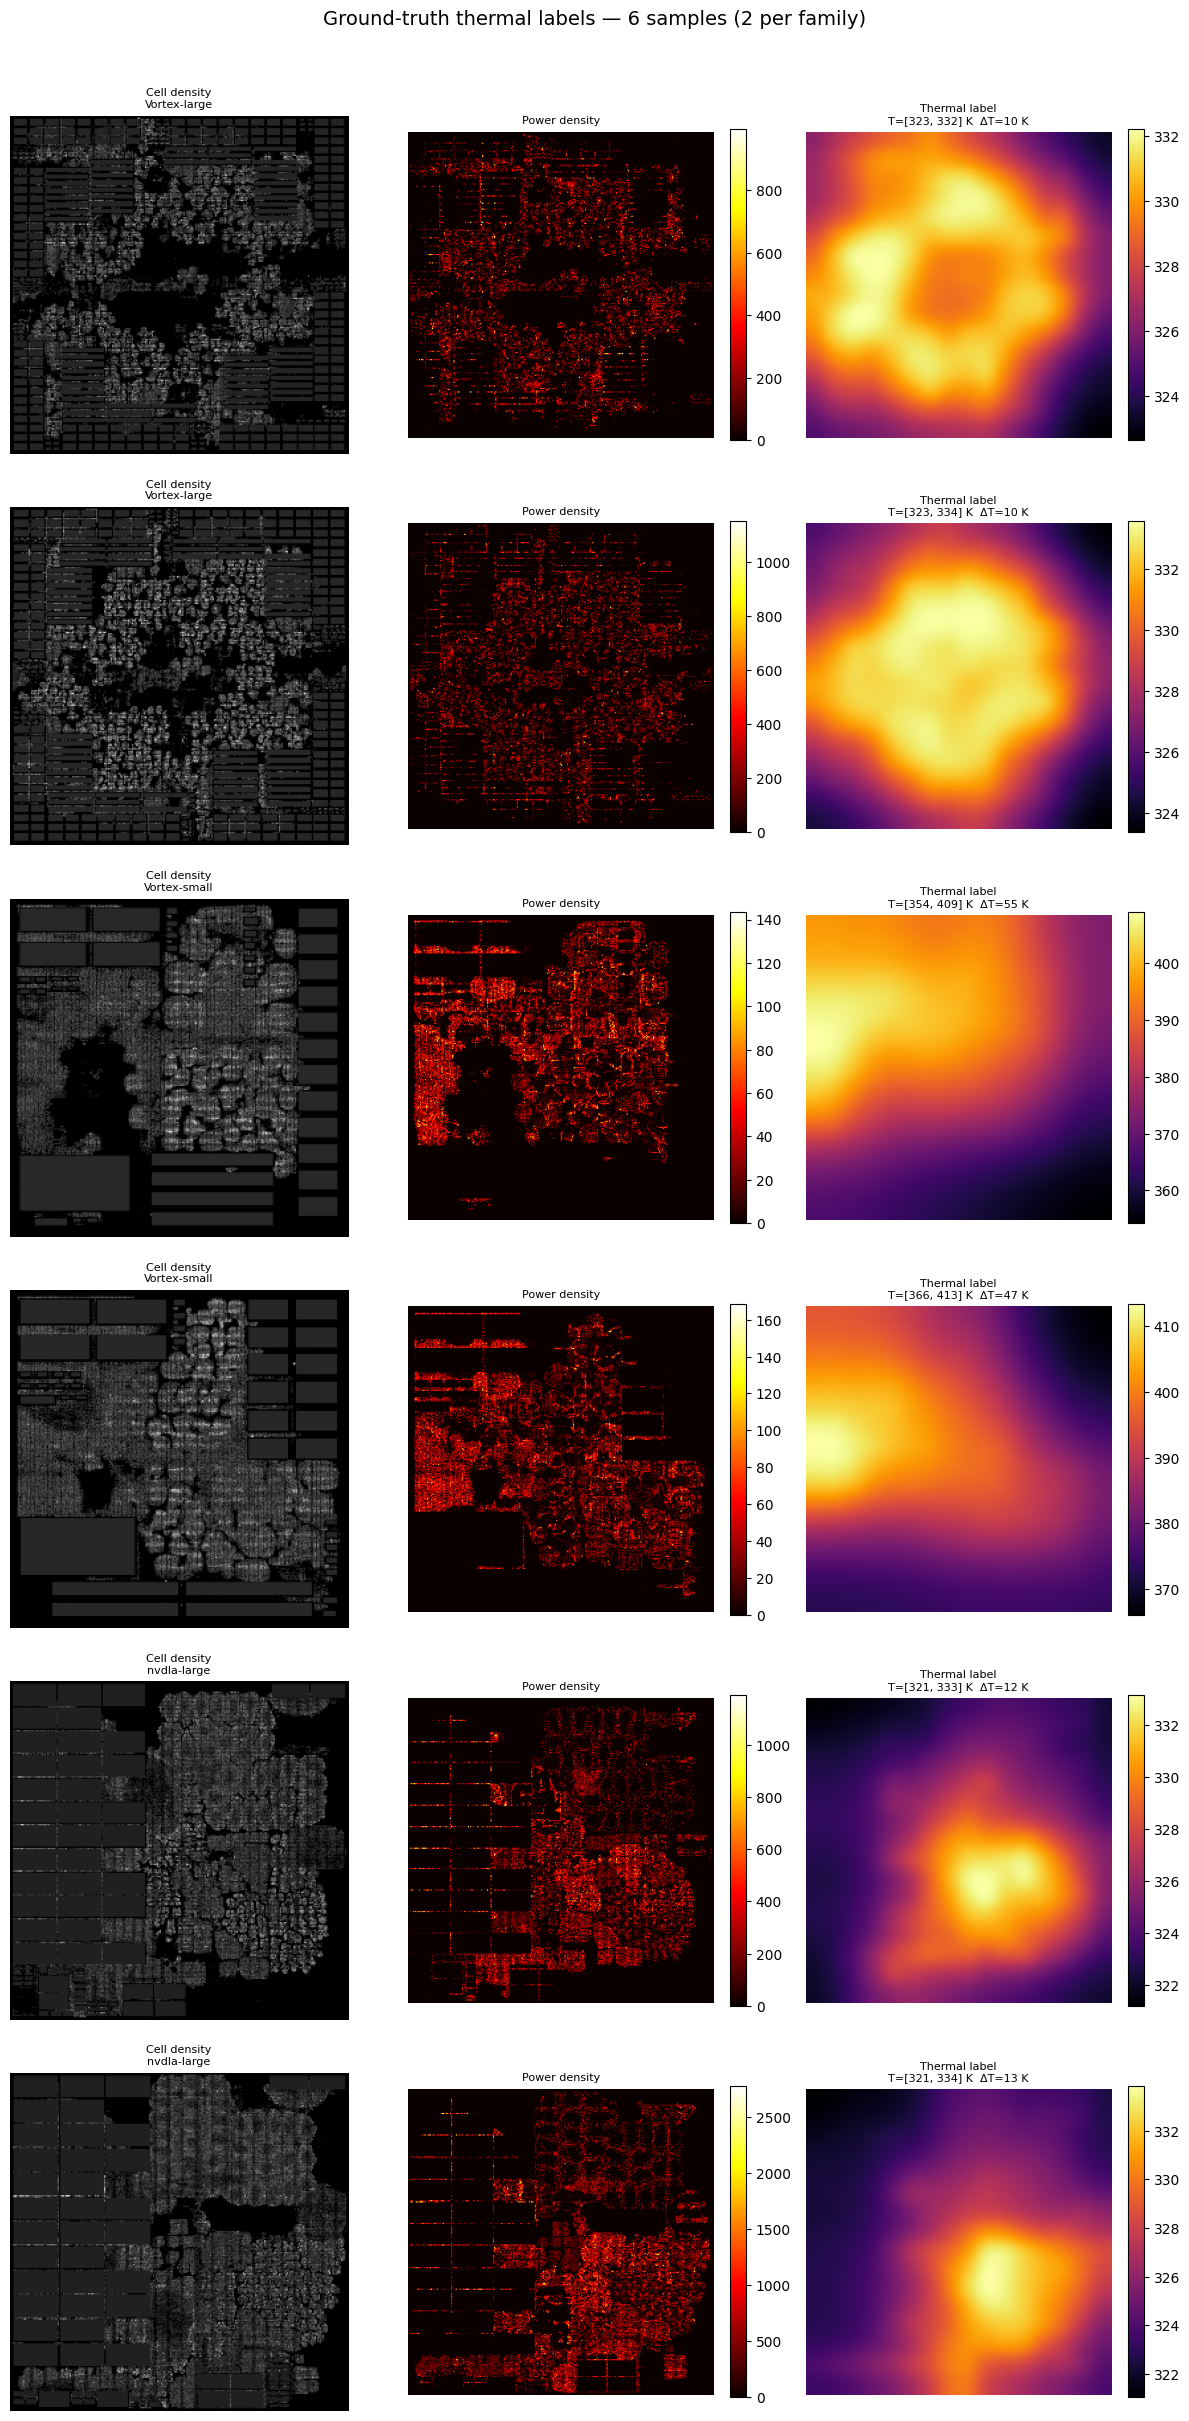

Saved to data/samples/label_overview.png


In [3]:
fig, axes = plt.subplots(len(rows), 3, figsize=(12, 4 * len(rows)))
fig.suptitle('Ground-truth thermal labels — 6 samples (2 per family)', fontsize=14, y=1.01)

for i, r in enumerate(rows):
    ax_fp, ax_pw, ax_th = axes[i]

    ax_fp.imshow(r['fp'], cmap='gray')
    ax_fp.set_title(f"Cell density\n{r['family']}", fontsize=8)
    ax_fp.axis('off')

    im_pw = ax_pw.imshow(r['power'], cmap='hot')
    ax_pw.set_title('Power density', fontsize=8)
    ax_pw.axis('off')
    plt.colorbar(im_pw, ax=ax_pw, fraction=0.046)

    im_th = ax_th.imshow(r['label'], cmap='inferno')
    ax_th.set_title(f"Thermal label\nT=[{r['T_min']:.0f}, {r['T_max']:.0f}] K  ΔT={r['T_max']-r['T_min']:.0f} K", fontsize=8)
    ax_th.axis('off')
    plt.colorbar(im_th, ax=ax_th, fraction=0.046)

plt.tight_layout()
plt.savefig('../data/samples/label_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to data/samples/label_overview.png')

In [4]:
# Stats summary across all 6 samples
print(f"{'Family':<15} {'Instance':<45} {'T_min':>7} {'T_max':>7} {'ΔT':>7} {'T_mean':>8}")
print('-' * 90)
for r in rows:
    print(f"{r['family']:<15} {r['name'][:44]:<45} {r['T_min']:>7.1f} {r['T_max']:>7.1f} {r['T_max']-r['T_min']:>7.1f} {r['T_mean']:>8.1f}")

Family          Instance                                        T_min   T_max      ΔT   T_mean
------------------------------------------------------------------------------------------
Vortex-large    Vortex-large_freq_200_mp_1_fpu_50_fpa_1.0_p_    322.6   332.2     9.6    328.8
Vortex-large    Vortex-large_freq_200_mp_1_fpu_55_fpa_1.0_p_    323.4   333.6    10.2    329.7
Vortex-small    Vortex-small_freq_200_mp_1_fpu_50_fpa_1.0_p_    354.2   409.0    54.8    382.7
Vortex-small    Vortex-small_freq_200_mp_1_fpu_55_fpa_1.0_p_    366.1   413.5    47.4    388.2
nvdla-large     nvdla-large_freq_200_mp_1_fpu_55_fpa_1.0_p_2    321.2   333.2    12.0    325.8
nvdla-large     nvdla-large_freq_500_mp_1_fpu_60_fpa_1.0_p_1    321.0   333.8    12.8    326.1
